# Generating grids for source sampling in CRpropa

This is just an example to show how the functions to compute grids work and used to create the SourceMassDistribution object used in CRpropa.

We use the same values for a DM halo in a cluster called Abel, from the `test_dmhalo` notebook.

You can check that the time to compute a cubic grid with $512^3$ cells takes only a couple of minutes (or less), with most of the time spent on passing values to the CRpropa grid.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from crpropa import Vector3d
from crpropa import Mpc

from elfdannagalac.dmsrc import (
    SmoothDMHaloMassDensityGrid,
    SmoothDMHaloMassSquaredDensityGrid,
    DMHalo,
    get_rhosat,
    prepareSmoothExtendedDMSource,
)

In [2]:
r200 = 3*u.Mpc
m200 = 3.545e14*u.Msun
rhosat = get_rhosat(100*u.GeV,3.6e-24*u.cm**3/u.s)

abel_cluster = DMHalo(
    "Abel",
    12*u.deg,
    27*u.deg,
    0.0308,
    m200,
    r200,
    dmsigmav=3.6e-24*u.cm**3/u.s,
    msub_min=3.5410271e9*u.Msun,
    msub_max=3.54e12*u.Msun,
    fsub=0.11,
    mpoints=5
)

2026-04-15 01:23:36.795 | WARNING  | elfdannagalac.dmsrc.halo:__init__:148 - Input R200 3.000 Mpc will be inconsistent with the rest of calculations.
 Setting R200 to the value obtained using the critical density: 1.406 Mpc
2026-04-15 01:24:05.055 | INFO     | elfdannagalac.dmsrc.halo:get_msub:651 - Computing mass in form of subhalos
2026-04-15 01:24:32.166 | INFO     | elfdannagalac.dmsrc.halo:get_average_subhalo_mass:713 - At this moment, the mass of the subhalo has not any dependance on the radial distance of the subhalo to the center of the host halo. Then, it is sufficient to just compute the average at the scale radius as the average subhalo mass is constant across the host halo.


In [3]:
abel_cluster.info

2026-04-15 01:24:34.895 | INFO     | elfdannagalac.dmsrc.halo:info:398 - 
Abel cluster configured with: 
	- Redshift: 0.031
	- D_lum: 129.474 Mpc
	- Coord: (12.000 deg,27.000 deg) [ICRS]
	- X: 112.841 Mpc
	- Y: 23.985 Mpc
	- Z: 58.780 Mpc
	- Cluster Radius [R200]: 1.406 Mpc
	- Total Mass [M200]: 3.545e+14 solMass
	- Scale radius: 0.086 Mpc
	- Scale density: 2.313e+16 solMass / Mpc3
	- Saturation Radius: 2.390e-10 Mpc
	- Saturation Density: 8.333e+24 solMass / Mpc3
	- Number of subhalos: 1116  (from [3.541e+09 solMass,3.540e+12 solMass])
	- Total mass in form of subhalos: 3.897e+13 solMass (11.0% of the cluster mass)
	- Average Subhalo Mass: 3.492e+10 solMass
	- Annihilation emissivity [No sub]: 1.431e+30 solMass2 / Mpc3 (6.058e+70 GeV2 / cm3)
	- Annihilation emissivity [With sub]: 1.431e+30 solMass2 / Mpc3 (6.058e+70 GeV2 / cm3)
	- Decay emissivity [No sub]: 3.545e+14 solMass (3.954e+71 GeV)
	- DM luminosity [Annihilation, No sub]: 3.49407e+42 erg / s
	- DM luminosity [Annihilation, Wi

In [4]:
ncells = 511
abel_cluster.cartcoord.xyz

<Quantity [112.84143961,  23.98518842,  58.78007081] Mpc>

In [5]:
dens = SmoothDMHaloMassDensityGrid(
    abel_cluster.cartcoord.xyz,
    abel_cluster.r200,
    ncells,
    abel_cluster
)

In [6]:
ccx   = abel_cluster.cartcoord.x.value
ccy   = abel_cluster.cartcoord.y.value
ccz   = abel_cluster.cartcoord.z.value
obs_r = abel_cluster.r200.value
xmesh = np.linspace(ccx-obs_r,ccx+obs_r,ncells)
ymesh = np.linspace(ccy-obs_r,ccy+obs_r,ncells)

ccx,ccy,ccz,obs_r

(np.float64(112.84143960636617),
 np.float64(23.98518841662465),
 np.float64(58.78007081334045),
 np.float64(1.406363176385843))

/tmp/ipykernel_1563480/3520648560.py:15: RuntimeWarning: divide by zero encountered in log10
  p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")


Text(0, 0.5, 'y [Mpc]')

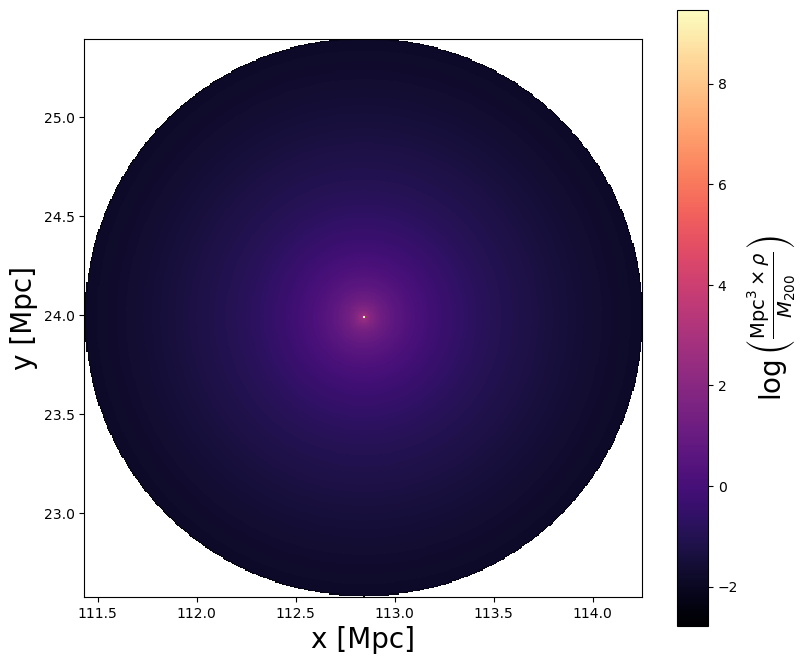

In [7]:

b_map = np.zeros((xmesh.size,ymesh.size))

for idx,x in enumerate(xmesh):
    for idy,y in enumerate(ymesh):

        val = dens.getDensity(Vector3d(x,y,ccz)*Mpc)
        # val = dens.interpolate(Vector3d(x,y,ccz)*Mpc)
        b_map[idx,idy] = val


fig,ax = plt.subplots(figsize=(9,8))

ax.set_aspect("equal")

p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")
c = fig.colorbar(p,)
c.set_label(label=r"$\log\left(\frac{\text{Mpc}^3\times\rho}{M_{200}}\right)$",fontsize=20)


ax.set_xlabel("x [Mpc]",fontsize=20)
ax.set_ylabel("y [Mpc]",fontsize=20)




In [8]:
max_dens_anna = b_map.max()
print(f"{b_map.max():0.5e}")

2.93841e+09


In [9]:
pdf_anna = SmoothDMHaloMassSquaredDensityGrid(
    abel_cluster.cartcoord.xyz,
    abel_cluster.r200,
    ncells,
    abel_cluster
)

/tmp/ipykernel_1563480/493047663.py:15: RuntimeWarning: divide by zero encountered in log10
  p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")


Text(0, 0.5, 'y [Mpc]')

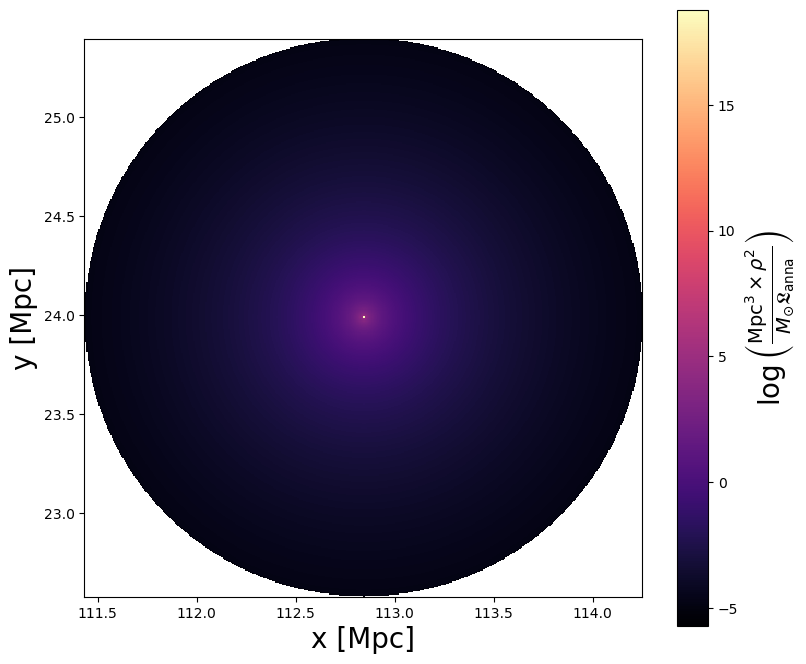

In [10]:
b_map = np.zeros((xmesh.size,ymesh.size))

for idx,x in enumerate(xmesh):
    for idy,y in enumerate(ymesh):

        val = pdf_anna.getDensity(Vector3d(x,y,ccz)*Mpc)
        # val = dens.interpolate(Vector3d(x,y,ccz)*Mpc)
        b_map[idx,idy] = val


fig,ax = plt.subplots(figsize=(9,8))

ax.set_aspect("equal")

p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")
c = fig.colorbar(p,)
c.set_label(label=r"$\log\left(\frac{\text{Mpc}^3\times\rho^2}{M_{\odot}\mathfrak{L}_\text{anna}}\right)$",fontsize=20)


ax.set_xlabel("x [Mpc]",fontsize=20)
ax.set_ylabel("y [Mpc]",fontsize=20)


In [11]:
max_dens_dec = b_map.max()
print(f"{b_map.max():0.5e}")

6.06808e+18


In [12]:
rmin = abel_cluster.cartcoord.xyz - abel_cluster.r200
rmax = abel_cluster.cartcoord.xyz + abel_cluster.r200

print(f"{rmin},{rmax}")

[111.43507643  22.57882524  57.37370764] Mpc,[114.24780278  25.39155159  60.18643399] Mpc


In [13]:
maxval_anna = abel_cluster.rho_sat**2/abel_cluster.l_dm_anna
maxval_dec = abel_cluster.rho_sat/abel_cluster.l_dm_decay

print(f"{maxval_anna:0.5e}")
print(f"{maxval_dec:0.5e}")

4.85447e+19 1 / Mpc3
2.35073e+10 1 / Mpc3


In [14]:
dmsrc_anna = prepareSmoothExtendedDMSource(
    pdf_anna,
    maxval_anna.value,
    int(1e9),
    rmin.to(u.m).value,
    rmax.to(u.m).value,
    abel_cluster.z,
    11,
    0.1,
    100.0,
    -2.0,
)

In [15]:
dmsrc_anna.getCandidate().source

Particle 11, E = 1.74745 EeV, x = 112.843 23.9848 58.7835 Mpc, p = -0.676037 0.72796 0.114228

In [16]:
dmsrc_dec = prepareSmoothExtendedDMSource(
    dens,
    maxval_dec.value,
    int(1e9),
    rmin.to(u.m).value,
    rmax.to(u.m).value,
    abel_cluster.z,
    11,
    0.1,
    100.0,
    -2.0,
)

dmsrc_dec.getCandidate().source

Particle 11, E = 3.4959 EeV, x = 112.846 23.9869 58.7832 Mpc, p = -0.395907 -0.717204 -0.573477

In [17]:
pdf_sub = SmoothDMHaloMassSquaredDensityGrid(
    abel_cluster.cartcoord.xyz,
    abel_cluster.r200,
    ncells,
    abel_cluster,
    subhalos = True
)

/tmp/ipykernel_1563480/2578969999.py:15: RuntimeWarning: divide by zero encountered in log10
  p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")


Text(0, 0.5, 'y [Mpc]')

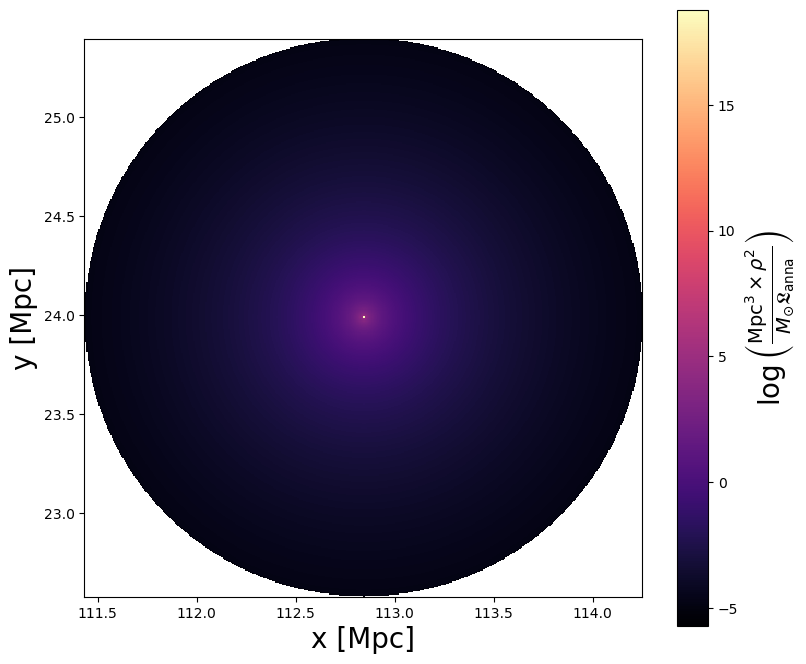

In [18]:
b_map = np.zeros((xmesh.size,ymesh.size))

for idx,x in enumerate(xmesh):
    for idy,y in enumerate(ymesh):

        val = pdf_sub.getDensity(Vector3d(x,y,ccz)*Mpc)
        # val = dens.interpolate(Vector3d(x,y,ccz)*Mpc)
        b_map[idx,idy] = val


fig,ax = plt.subplots(figsize=(9,8))

ax.set_aspect("equal")

p = ax.pcolormesh(xmesh,ymesh,np.log10(b_map.T),cmap="magma")
c = fig.colorbar(p,)
c.set_label(label=r"$\log\left(\frac{\text{Mpc}^3\times\rho^2}{M_{\odot}\mathfrak{L}_\text{anna}}\right)$",fontsize=20)


ax.set_xlabel("x [Mpc]",fontsize=20)
ax.set_ylabel("y [Mpc]",fontsize=20)
